# The Gold Lease Rate — does the cost to *borrow* gold predict its price? 🪙
### An obscure bullion-market number, and whether it can time gold — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Gold isn't just bought and sold — it's also **lent**. Banks and refiners borrow physical bullion, and the price they pay is the **gold lease rate**. When metal is scarce and everyone wants it *now*, that borrow cost spikes. Bullion-market folklore says those spikes are a **crystal ball**: a jump in the cost to borrow gold today supposedly foreshadows a gold *rally* tomorrow.

It's the kind of clever, obscure signal that sounds like an edge. So we test it. But there's a catch you'll meet in a moment — **the data was switched off in 2015** — so we have to build a synthetic world instead, and be honest about what that does and doesn't prove.

> 📓 **This is the plain-language layer.** Want the regressions, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_lease_rate import data, strategy as st

# SYNTHETIC-ONLY: no real tape exists (LBMA discontinued GOFO 2015-01-30). Everything below runs
# on the deterministic, offline generator (seed 580) and is reproducible for any reader offline.
HAVE_REAL = not data.fetch_series(fetch=False).empty   # always False by design
NULL,  _ = data.synthetic_series(lead_beta=0.0,  lag=1, seed=580)   # the honest headline world
CTRL,  _ = data.synthetic_series(lead_beta=0.02, lag=1, seed=580)   # the planted positive control
print("real lease-rate tape present:", HAVE_REAL, "(synthetic-only study — GOFO discontinued 2015)")
print("null world fp:", data.fingerprint(NULL), "| positive-control fp:", data.fingerprint(CTRL))


real lease-rate tape present: False (synthetic-only study — GOFO discontinued 2015)
null world fp: 756d06b1b283 | positive-control fp: e3ed82fc53fe


## The answer first 🎯

| Question | Answer |
|---|---|
| Can we test this on *real* gold-lease data? | **No.** The one clean public source — the LBMA's daily **GOFO** benchmark — was **discontinued on 2015-01-30**. No free, continuous lease-rate history exists. |
| So what did we do? | Built a **synthetic world** where we can *turn the signal on or off* and check the engine catches it. |
| When the signal is OFF (the null), does the engine cry wolf? | **No.** The lead-lag comes out flat (slope-*t* **+0.08**, a shuffle test *p* = 0.936). Good — no false alarm. |
| When the signal is ON, does the engine catch it? | **Yes** — slope-*t* jumps to **+7.73**, and it holds up across 25 different random worlds. |
| So could you trade the folklore? | **No** — there's nothing to trade (no lease-rate product), and even the trading rule *loses to just holding gold* in the null world. |

> The honest verdict is **`WEAK × MIRAGE`**: a well-built engine with **no real data to point it at**. We can prove the machinery works — we can't prove the folklore does.

## 1 · The claim

> *"A spike in the gold lease rate — the cost to borrow bullion — foreshadows a rise in the gold price."* — commodity-microstructure folklore.

The story: the lease rate is roughly `LIBOR − GOFO`, where **GOFO** was the rate to swap gold for dollars. When physical metal is tight (a scramble, *backwardation*), the lease rate spikes — and, the folklore says, that tightness spills into the spot price soon after. A borrow-cost signal that *leads* the price would be a genuine edge, because almost nobody watches it.

## 2 · So what?

If it were true, an obscure plumbing rate would time one of the world's most-watched assets — a clean, uncrowded signal. The desk has looked at gold through **ratios** ([113 gold-silver](../../113-gold-silver-ratio/), [305 gold-oil](../../305-gold-oil-ratio/), [388 lumber-gold](../../388-lumber-gold-ratio/)) and through the [miners' equity beta](../../208-gold-miners/). This one is different: a **microstructure carry/borrow** signal, the gold cousin of a *convenience yield*.

## 3 · How would we even know?

Simple, in principle:

1. Each month, note the **lease rate** (standardised, so 'high' and 'low' are comparable over time).
2. Look at gold's return over the **following** month.
3. Does a high lease rate this month go with a higher gold return next month? Fit a line; check the slope.

**The catch:** there's no free lease-rate history to run this on. GOFO ended in 2015. So we build a **synthetic** monthly world where we control the truth — a lease rate that mean-reverts and occasionally spikes (like the real one), and a knob that decides whether it *actually* predicts gold. With the knob at zero (the *null*), it predicts nothing. That null is our honest headline.

## 4 · The teardown — let's actually look

First, what does the synthetic lease rate look like? A calm baseline with occasional **spikes** — physical scrambles.

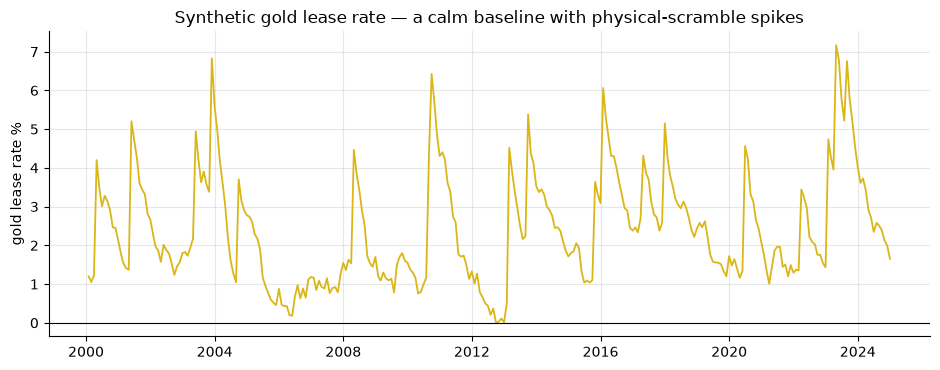

lease rate: mean 2.41%, max 7.17%


In [2]:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(NULL.index, NULL['lease_rate']*100, color=AMBER, lw=1.3)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('gold lease rate %')
ax.set_title('Synthetic gold lease rate — a calm baseline with physical-scramble spikes')
plt.tight_layout(); plt.show()
print(f"lease rate: mean {NULL['lease_rate'].mean()*100:.2f}%, max {NULL['lease_rate'].max()*100:.2f}%")

**Now the test.** In the *null* world (signal OFF), does a high lease rate this month foreshadow a higher gold return next month? Plot next-month gold return against this month's lease-rate level.

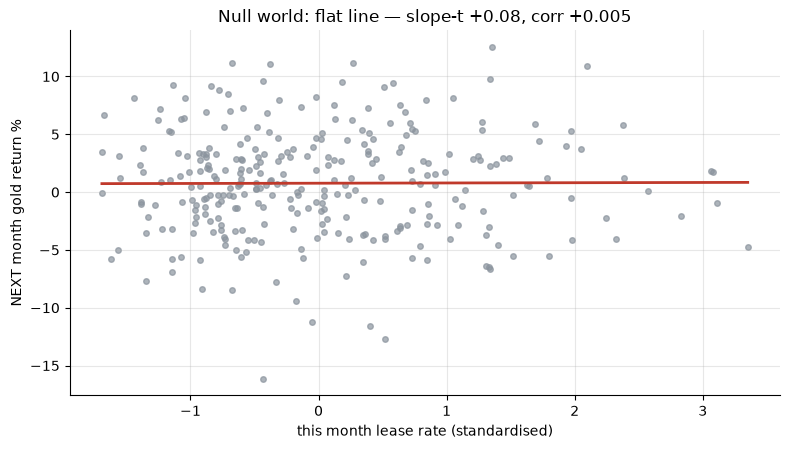

null world: slope-t +0.08, correlation +0.005, R2 0.000


In [3]:
reg = st.predictive_regression(NULL, lag=1)
x = NULL['lease_z'].to_numpy()[:-1]; y = NULL['gold_ret'].to_numpy()[1:]*100
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=16, color=GREY, alpha=.7)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, (reg['b']*xs + (y.mean()/100 - reg['b']*x.mean()))*100, c=RED, lw=2)
ax.set_xlabel('this month lease rate (standardised)'); ax.set_ylabel('NEXT month gold return %')
ax.set_title(f"Null world: flat line — slope-t {reg['t']:+.2f}, corr {reg['corr']:+.3f}")
plt.tight_layout(); plt.show()
print(f"null world: slope-t {reg['t']:+.2f}, correlation {reg['corr']:+.3f}, R2 {reg['r2']:.3f}")

A **flat cloud** — no relationship. Slope-*t* **+0.08**, correlation **+0.005**. That's exactly what 'no signal' looks like, and it's the honest headline: with no real data, the default synthetic world carries no lead-lag.

**But is the engine just blind?** Flip the knob ON (plant a real lead-lag) and re-run. If the engine is any good, it should now light up.

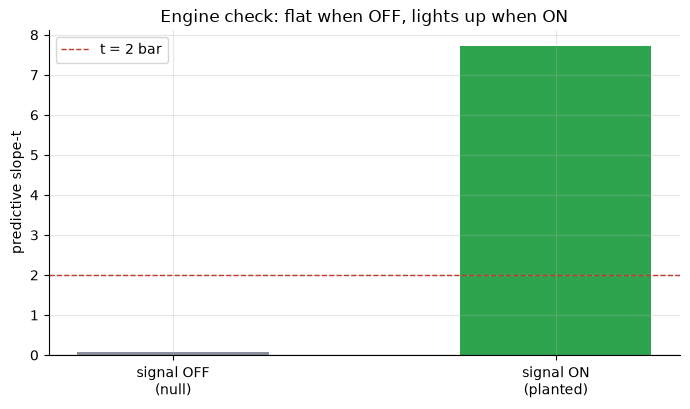

signal OFF t +0.08  |  signal ON t +7.73


In [4]:
r_null = st.predictive_regression(NULL, lag=1)['t']
r_ctrl = st.predictive_regression(CTRL, lag=1)['t']
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['signal OFF\n(null)','signal ON\n(planted)'], [r_null, r_ctrl], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('predictive slope-t'); ax.legend()
ax.set_title('Engine check: flat when OFF, lights up when ON')
plt.tight_layout(); plt.show()
print(f'signal OFF t {r_null:+.2f}  |  signal ON t {r_ctrl:+.2f}')

When the lead-lag is really there, the engine catches it (slope-*t* **+7.73**, well past the *t* = 2 bar). So the flat null result is a statement about the **absence of a planted signal**, not a broken detector.

## 5 · The verdict

- **Signal — Weak.** There is **no real lease-rate tape** (GOFO ended 2015), so the axis is capped at *Weak* — we cannot earn *Real* (that needs a robust result on real data). The null world is flat; the engine is faithful.
- **Tradability — Mirage.** No lease-rate product to trade, the rate is quoted in arrears with a wide spread, and the trading rule *underperforms just holding gold* in the null world.

## 6 · Could you actually trade it?

Even pretending the signal were real, you couldn't: there's no gold-lease ETF, the rate is published in arrears with a wide bid/ask, and the operational rule — *hold gold when the lease rate is high, else sit in cash* — spends more than half its life in cash and so **gives up gold's drift**. In the null world it earns about **+4.7%/yr** versus **+9.2%/yr** for simply buying and holding gold. Mirage.

## 7 · Going further 🚪

- **The data is the whole problem.** If you can source a real, continuous gold-lease-rate series (reconstructed GOFO, a data vendor's implied lease rate), drop it into the study's `_cache/` and re-run — the engine is ready and waiting.
- **Neighbours.** Gold through ratios: [113 gold-silver](../../113-gold-silver-ratio/), [305 gold-oil](../../305-gold-oil-ratio/); through miners: [208 gold-miners](../../208-gold-miners/).

*Think the lease rate really does lead gold? Find the tape, feed it in, and show the slope clearing t = 2 the right way.*